# 03 — GLM inference: continuous predictor + confound partialling

When the design has a continuous variable of interest (age, severity,
IQ…) and you want to regress out confounds (motion, sex), use
`compute_p_val_glm` instead of `compute_p_val`.

Under the hood: **Freedman-Lane permutation** — residuals of the
reduced (confounds-only) model are permuted, then the full model is
refit per permutation. This preserves the confound structure.

This notebook demonstrates:

1. Convenience API: `interest=` and `confounds=`.
2. Advanced API: explicit `design_matrix` and `contrast`.
3. That ignoring a correlated confound inflates false positives.

Runtime target: ~45 s.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from conninfpy import (
    TopologyDatasetGenerator,
    compute_p_val_glm,
    fisher_r_to_z,
)

Matplotlib is building the font cache; this may take a moment.


/opt/homebrew/Caskroom/miniforge/base/envs/fmri-fitting/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Synthesize an age-driven effect with a motion confound

Baseline Y comes from a realistic modular covariance (no group effect).
We plant a single edge where higher `age` increases connectivity, and
generate `motion` correlated with age — so if you ignore motion, some
age-related signal leaks into confounded edges.

In [2]:
N, n_sub = 30, 40
gen = TopologyDatasetGenerator(n_nodes=N, n_modules=3, seed=3)
ds = gen.generate("within_module_dense", effect_size=0.0,
                  n_samples=n_sub, time_points=60)
Y = fisher_r_to_z(ds.group1).copy()

rng = np.random.RandomState(3)
age = rng.randn(n_sub)
motion = 0.85 * age + np.sqrt(1 - 0.85**2) * rng.randn(n_sub)

# Plant a single-edge age effect (Fisher-z space is unbounded).
edge = (1, 5)
beta = 1.2
for s in range(n_sub):
    Y[s, edge[0], edge[1]] += beta * age[s]
    Y[s, edge[1], edge[0]] += beta * age[s]

# Also add a motion-driven nuisance cluster elsewhere to make the
# confound matter.
nuisance_edges = [(10, 12), (10, 13), (11, 13)]
for s in range(n_sub):
    for i, j in nuisance_edges:
        Y[s, i, j] += 1.0 * motion[s]
        Y[s, j, i] += 1.0 * motion[s]

print("Y:", Y.shape, " age:", age.shape, " corr(age, motion) =",
      round(float(np.corrcoef(age, motion)[0, 1]), 3))

Y: (40, 30, 30)  age: (40,)  corr(age, motion) = 0.832


## 2. Convenience API: with vs without confound

Passing `confounds=motion` partials it out via Freedman-Lane.
Omitting it lets motion masquerade as an age effect.

In [3]:
%%time
p_nomotion = compute_p_val_glm(
    Y, interest=age,
    method="tfnbs", n_permutations=300,
    rng=0, use_mp=False,
)
p_motion = compute_p_val_glm(
    Y, interest=age, confounds=motion,
    method="tfnbs", n_permutations=300,
    rng=0, use_mp=False,
)

CPU times: user 219 ms, sys: 22.7 ms, total: 241 ms
Wall time: 277 ms


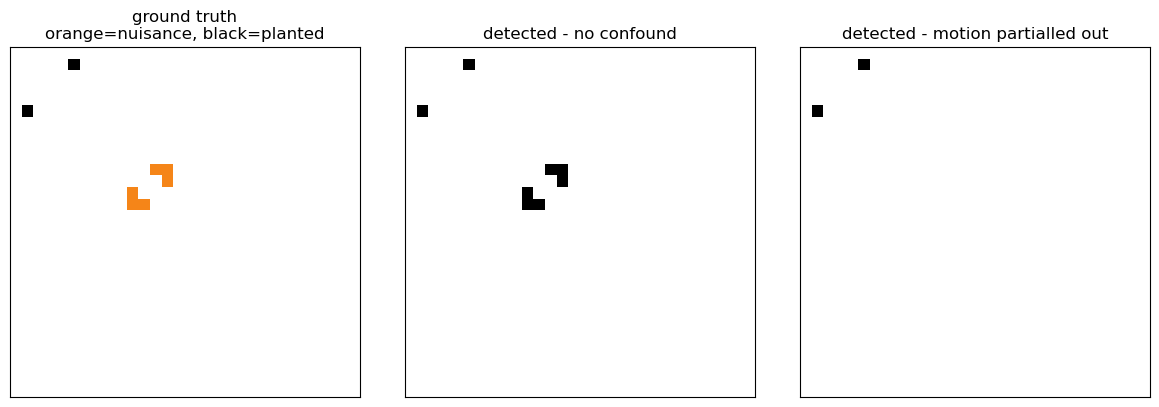

Nuisance edges flagged significant - without confound: 3, with confound: 0


In [4]:
alpha = 0.05
planted = np.zeros((N, N), dtype=bool)
planted[edge[0], edge[1]] = planted[edge[1], edge[0]] = True
nuisance = np.zeros_like(planted)
for i, j in nuisance_edges:
    nuisance[i, j] = nuisance[j, i] = True

truth = np.zeros((N, N), dtype=int)
truth[nuisance] = 1
truth[planted] = 2
truth_cmap = ListedColormap(["white", "#f58518", "black"])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(truth, cmap=truth_cmap, vmin=0, vmax=2)
axes[0].set_title("ground truth\norange=nuisance, black=planted")
axes[1].imshow(p_nomotion['positive'] < alpha, cmap="Greys")
axes[1].set_title("detected - no confound")
axes[2].imshow(p_motion['positive'] < alpha, cmap="Greys")
axes[2].set_title("detected - motion partialled out")
for a in axes: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

# Nuisance-edge false positives when motion is ignored:
fp_no  = int((p_nomotion['positive'][nuisance] < alpha).sum() // 2)
fp_yes = int((p_motion['positive'][nuisance]   < alpha).sum() // 2)
print(f"Nuisance edges flagged significant - without confound: {fp_no}, with confound: {fp_yes}")

## 3. Advanced API: explicit design matrix + contrast

Useful when you need non-trivial contrasts (e.g. a group × age
interaction, or a two-column basis for the variable of interest).

In [5]:
X = np.column_stack([
    np.ones(n_sub),       # intercept
    age,                  # interest
    motion,               # confound
])
contrast = np.array([0.0, 1.0, 0.0])  # test the age column

p_adv = compute_p_val_glm(
    Y,
    design_matrix=X, contrast=contrast,
    method="tfnbs", n_permutations=300,
    rng=0, use_mp=False,
)
np.testing.assert_allclose(p_adv['positive'], p_motion['positive'])
print("Advanced API matches the convenience API ✓")

Advanced API matches the convenience API ✓


## 4. Binary interest: group comparison with confound partialling

The `interest` vector can be **binary** (0/1) — the GLM contrast then
tests the conditional mean difference between groups, with confounds
partialled out via Freedman-Lane. This is the right tool when:

- you have a two-group design, AND
- you need to regress out a nuisance (motion, sex, age, site...)

If you have **no** confounds, `compute_p_val(test_type='two-sample')`
gives the same answer with less machinery — prefer that.

Here we derive a motion-confounded group indicator from age, then add a
small group-coded effect at the same planted edge. The nuisance cluster
stays motion-driven, so it should disappear after motion is partialled out.

In [6]:
# Binary interest derived from age, so group remains correlated with motion.
group = (age > np.median(age)).astype(float)

# Make a binary-demo copy with an explicit group-coded effect at the same
# planted edge. Centering keeps the global scale comparable across groups.
Y_group = Y.copy()
group_effect = 1.0
centered_group = group - group.mean()
for s in range(n_sub):
    Y_group[s, edge[0], edge[1]] += group_effect * centered_group[s]
    Y_group[s, edge[1], edge[0]] += group_effect * centered_group[s]

print(f"group 0: {int((group == 0).sum())} subjects,  "
      f"group 1: {int((group == 1).sum())} subjects")
print(f"corr(group, motion) = {np.corrcoef(group, motion)[0, 1]:.3f}")

group 0: 20 subjects,  group 1: 20 subjects
corr(group, motion) = 0.689


In [7]:
%%time
# Binary interest + motion confound — Freedman-Lane partials motion out.
p_group = compute_p_val_glm(
    Y_group,
    interest=group, confounds=motion,
    method="tfnbs", n_permutations=300,
    rng=0, use_mp=False,
)
# p_group['positive'] — edges higher in group 1 than group 0
# p_group['negative'] — edges higher in group 0 than group 1

CPU times: user 67.5 ms, sys: 2.4 ms, total: 69.9 ms
Wall time: 69.9 ms


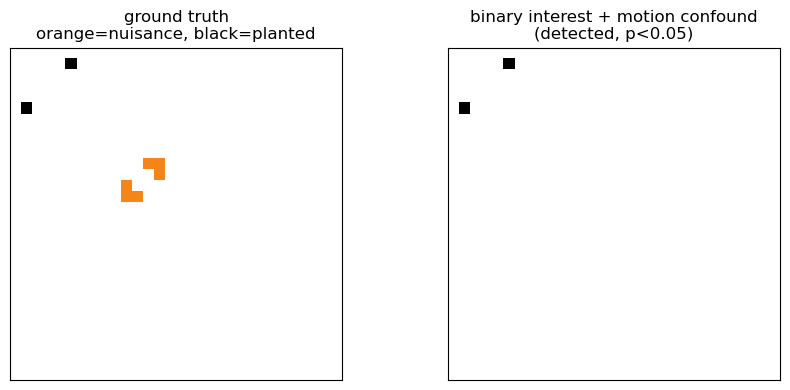

planted edge detected: True;  nuisance false positives: 0


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(truth, cmap=truth_cmap, vmin=0, vmax=2)
axes[0].set_title("ground truth\norange=nuisance, black=planted")
axes[1].imshow(p_group['positive'] < 0.05, cmap="Greys")
axes[1].set_title("binary interest + motion confound\n(detected, p<0.05)")
for a in axes: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

fp_bin = int((p_group['positive'][nuisance] < 0.05).sum() // 2)
tp_bin = int((p_group['positive'][planted] < 0.05).sum() // 2)
print(f"planted edge detected: {bool(tp_bin)};  nuisance false positives: {fp_bin}")

**Practical notes for binary / categorical designs**

- Binary coding is 0/1. The sign of `'positive'` / `'negative'` refers
  to the 1-coded group being **larger** / **smaller**.
- Multi-level categoricals (e.g. 3 diagnostic groups) need
  **dummy-coded columns** (`k-1` columns for a `k`-level factor).
  Pass them either through the advanced API with a contrast vector
  targeting the relevant column, or via `confounds=` if they are
  nuisance rather than of interest.
- Unbalanced groups are fine — Freedman-Lane exchangeability holds
  after the reduced-model residualization.
- For a categorical of **interest with no confounds**, use
  `compute_p_val(test_type='two-sample', method='tfnbs')` instead —
  simpler and mathematically equivalent.

## Discussion

- GLM output keys are `'positive'` / `'negative'` (edges where
  interest ↑ → connectivity ↑ or ↓).
- `two_tailed=True` switches to a joint max-null instead of per-tail
  FWER — stricter, equivalent to an absolute-value test.
- All 6 enhancement methods (tfnbs, nbs, cnbs, ni_tfnbs, fbc_tfnbs,
  tstat) are supported via the same `method=` argument.
- For speed, combine with `acceleration='gpd'` — see **notebook 04**.